In [1]:
import re, sys, os
from pathlib import Path
import torch
import numpy as np
repo_start = f'../'
sys.path.append(repo_start)

from modules.utils.imports import *
from modules.binn_eql.model_wrapper_2d import model_wrapper
from modules.binn_eql.build_binn_eql_net import BINN
# from modules.binn_eql_hypernet.build_binn_eql_net import BINN
from modules.loaders.format_data import format_data_general, format_data_torch

In [2]:
def extract_final_loss(filepath):
    """
    Reads the given file and extracts the validation loss (as a float)
    from the line containing the word 'Elapsed'.
    """
    # Regular expression to capture the validation loss
    # This regex looks for "Val loss = " followed by a floating point number (possibly in scientific notation)
    val_loss_pattern = re.compile(r"Val loss = ([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)")
    
    with open(filepath, 'r') as file:
        for line in file:
            # Check if the line contains "Elapsed"
            if "Elapsed" in line:
                # Search the line for the pattern
                match = val_loss_pattern.search(line)
                if match:
                    try:
                        return float(match.group(1))
                    except ValueError:
                        print(f"Conversion error in file {filepath} for line: {line.strip()}")
                        return None
    # If no matching line was found
    return None

def extract_final_loss_fine_tuned(filepath):
    """
    Reads the given file and extracts the validation loss (as a float)
    from the line containing the word 'Elapsed'.
    """
    val_losses = []
    # Regular expression to capture the validation loss
    # This regex looks for "Val loss = " followed by a floating point number (possibly in scientific notation)
    val_loss_pattern = re.compile(r"Val loss = ([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)")
    
    with open(filepath, 'r') as file:
        for line in file:
            # Check if the line contains "Elapsed"
            if "Elapsed" in line:
                # Search the line for the pattern
                match = val_loss_pattern.search(line)
                if match:
                    try:
                        val_losses.append(float(match.group(1)))
                    except ValueError:
                        print(f"Conversion error in file {filepath} for line: {line.strip()}")
                        return None
        return val_losses[1] if len(val_losses) >= 2 else None
    # If no matching line was found
    return None

def process_directory(parent_dir, fine_tuned=False):
    """
    For each subdirectory under parent_dir, finds slurm files with the pattern "slurm-####.out",
    selects the one with the lower number, extracts the validation loss, and prints the subdirectory path
    alongside the extracted loss.
    """
    results = {}
    # Use pathlib to iterate over subdirectories
    for subdir in Path(parent_dir).iterdir():
        if subdir.is_dir():
            # Find files matching pattern "slurm-*.out"
            slurm_files = list(subdir.glob("slurm-*.out"))
            if not slurm_files:
                # print(f"No slurm files found in {subdir}")
                results[str(subdir)] = None
                continue
            
            # Extract numeric part from filename (assumes naming: slurm-####.out)
            def extract_number(file_path):
                match = re.search(r"slurm-(\d+)\.out", file_path.name)
                return int(match.group(1)) if match else float('inf')
            
            # Sort files by the extracted number
            slurm_files.sort(key=extract_number)
            # Take the first file (lowest number)
            first_file = slurm_files[0]
            if fine_tuned:
                val_loss = extract_final_loss_fine_tuned(first_file)
            else:
                val_loss = extract_final_loss(first_file)
            if val_loss is not None:
                results[str(subdir)] = val_loss
            else:
                # print(f"Could not extract validation loss from file {first_file} in {subdir}")
                results[str(subdir)] = None
    
    return results

data = torch.load('/work/users/s/m/smyersn/elston/projects/kinetics_binns/data/2d/pos_feedback/a_1.0_b_1_k_0.01.pt')
u_array, x_array, t_array = data['u_array'], data['x_array'], data['t_array']
training_data = format_data_torch(u_array, x_array, t_array)

In [8]:
# parent_directory = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/pos_feedback/69_fewer_dupes_shorter_warmup/a_5.0_b_1_k_0.01'
parent_directory = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/pos_feedback/78_final_pos_test/a_5.0_b_1_k_0.01'

losses = process_directory(parent_directory, fine_tuned=False)

# Sort the results by validation loss (lowest first)
sorted_losses = sorted(losses.items(), key=lambda item: (item[1] is None, item[1]))

# Print the sorted results
for dir_name, val_loss in sorted_losses:
    if val_loss:
        print(f"\nDirectory: {dir_name.split('/')[-1]}")
        print(f"Validation Loss: {val_loss}")
        
        # Load model
        binn = BINN(
            dimensions=2,
            species=2, 
            train_data=training_data, 
            diff_coeffs=[0.01, 1],
            # uv_layers=[256, 256, 256, 256, 2],
            # diff_coeffs=(),
            duplicates=5)
            # duplicates=20)

        binn.to('cpu')

        parameters = binn.parameters()

        opt = torch.optim.Adam(parameters, lr=0.001)

        model = model_wrapper(
            model=binn,
            optimizer=opt,
            loss=binn.loss,
            dir_name=dir_name,
            save_name=f'{dir_name}/binn')
                
        model.load(f"{dir_name}/binn_best_val_model", device='cpu')
        # model.model.prune(thresh=5)
        # Print equation
        fn = f'{dir_name}/equation.txt'
        for term in model.model.generate_equation():
            print(f'{term}')
        
        model.model.fine_tune_eql(threshold=0.01, epsilon=0.1)
        for term in model.model.generate_equation():
            print(f'{term}')
            
        if not model.model.diff_coeffs:          
            print(f'{[D.item() for D in model.model.diffusion_fitter()]}\n')



Directory: binn_eql_l0_1_duplicates_5_warm_up_20000_lux_tax_1_repeat_2
Validation Loss: 2.0278
3.213 * v * u^2.154 / (1 + 0.013 * u^2.154)
-0.068 * u * (1 / 0.096 - v^1.273 / (1 + 0.096 * v^1.273))
Simplifying Hill 64 -> Poly 0
  Error: 0.0021, Multiplier: 10.3942
Fine-tuning committed.
-0.705 * u
3.213 * v * u^2.154 / (1 + 0.013 * u^2.154)

Directory: binn_eql_l0_1_duplicates_5_warm_up_20000_lux_tax_1_repeat_5
Validation Loss: 2.033
2.680 * v * u^2.258 / (1 + 0.014 * u^2.258)
-0.081 * u * (1 / 0.128 - v^1.197 / (1 + 0.128 * v^1.197))
Simplifying Hill 48 -> Poly 0
  Error: 0.0033, Multiplier: 7.7935
Fine-tuning committed.
-0.633 * u
2.680 * v * u^2.258 / (1 + 0.014 * u^2.258)

Directory: binn_eql_l0_1_duplicates_5_warm_up_20000_lux_tax_1_repeat_4
Validation Loss: 2.0539
3.176 * v * u^2.135 / (1 + 0.046 * u^2.135)
-1.209 * u^1.040 / (1 + 0.535 * u^1.040)
Fine-tuning committed.
3.176 * v * u^2.135 / (1 + 0.046 * u^2.135)
-1.209 * u^1.040 / (1 + 0.535 * u^1.040)

Directory: binn_eql_l0_1

In [32]:
# Load model
binn = BINN(
    dimensions=2,
    species=2, 
    train_data=training_data, 
    diff_coeffs=[0.01, 1],
    # uv_layers=[256, 256, 256, 256, 2],
    # diff_coeffs=(),
    duplicates=5)

binn.to('cpu')

parameters = binn.parameters()

opt = torch.optim.Adam(parameters, lr=0.001)

model = model_wrapper(
    model=binn,
    optimizer=opt,
    loss=binn.loss,
    dir_name=dir_name,
    save_name=f'{dir_name}/binn')

model.load(f"/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/pos_feedback/76_more_l0_loss/a_1.0_b_1_k_0.01/binn_eql_l0_2_duplicates_5_warm_up_20000_lux_tax_1_repeat_3/binn_best_val_model", device='cpu')

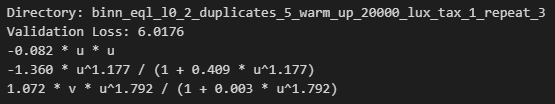
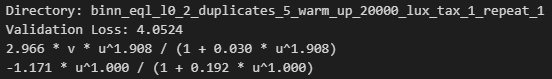

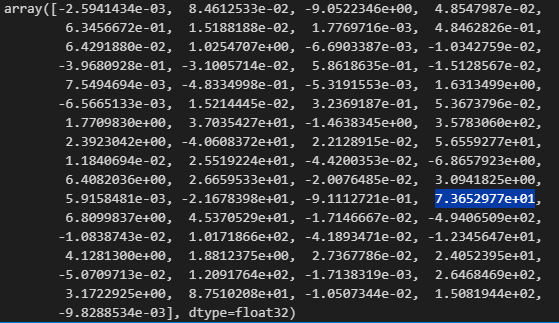
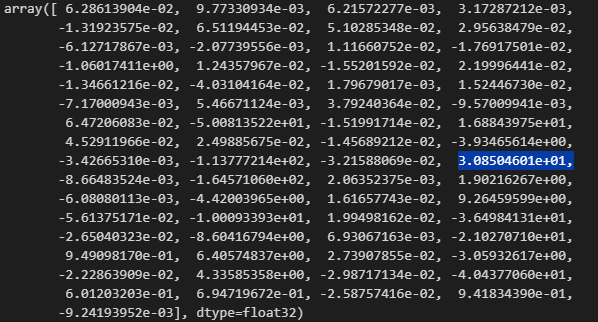

For a = 1, coefficients generally less than 100

In [ ]:
param_dict = model.model.extract_params()
param_dict.keys() 44

dict_keys(['raw_w', 'raw_w_unscaled', 'gates', 'effective', 'effective_unscaled', 'num_poly', 'num_hill', 'ns_inc', 'Ks_inc', 'ns_dec', 'Ks_dec', 'poly_terms', 'hill_terms', 'poly_coeffs_unscaled', 'hill_inc_unscaled', 'hill_dec_unscaled', 'Ks_inc_unscaled', 'Ks_dec_unscaled'])

In [35]:
param_dict['raw_w']
# param_dict['effective']

array([-2.5941434e-03,  8.4612533e-02, -9.0522346e+00,  4.8547987e-02,
        6.3456672e-01,  1.5188188e-02,  1.7769716e-03,  4.8462826e-01,
        6.4291880e-02,  1.0254707e+00, -6.6903387e-03, -1.0342759e-02,
       -3.9680928e-01, -3.1005714e-02,  5.8618635e-01, -1.5128567e-02,
        7.5494694e-03, -4.8334998e-01, -5.3191553e-03,  1.6313499e+00,
       -6.5665133e-03,  1.5214445e-02,  3.2369187e-01,  5.3673796e-02,
        1.7709830e+00,  3.7035427e+01, -1.4638345e+00,  3.5783060e+02,
        2.3923042e+00, -4.0608372e+01,  2.2128915e-02,  5.6559277e+01,
        1.1840694e-02,  2.5519224e+01, -4.4200353e-02, -6.8657923e+00,
        6.4082036e+00,  2.6659533e+01, -2.0076485e-02,  3.0941825e+00,
        5.9158481e-03, -2.1678398e+01, -9.1112721e-01,  7.3652977e+01,
        6.8099837e+00,  4.5370529e+01, -1.7146667e-02, -4.9406509e+02,
       -1.0838743e-02,  1.0171866e+02, -4.1893471e-02, -1.2345647e+01,
        4.1281300e+00,  1.8812375e+00,  2.7367786e-02,  2.4052395e+01,
      

In [25]:
param_dict['raw_w']

array([-2.5941434e-03,  8.4612533e-02, -9.0522346e+00,  4.8547987e-02,
        6.3456672e-01,  1.5188188e-02,  1.7769716e-03,  4.8462826e-01,
        6.4291880e-02,  1.0254707e+00, -6.6903387e-03, -1.0342759e-02,
       -3.9680928e-01, -3.1005714e-02,  5.8618635e-01, -1.5128567e-02,
        7.5494694e-03, -4.8334998e-01, -5.3191553e-03,  1.6313499e+00,
       -6.5665133e-03,  1.5214445e-02,  3.2369187e-01,  5.3673796e-02,
        1.7709830e+00,  3.7035427e+01, -1.4638345e+00,  3.5783060e+02,
        2.3923042e+00, -4.0608372e+01,  2.2128915e-02,  5.6559277e+01,
        1.1840694e-02,  2.5519224e+01, -4.4200353e-02, -6.8657923e+00,
        6.4082036e+00,  2.6659533e+01, -2.0076485e-02,  3.0941825e+00,
        5.9158481e-03, -2.1678398e+01, -9.1112721e-01,  7.3652977e+01,
        6.8099837e+00,  4.5370529e+01, -1.7146667e-02, -4.9406509e+02,
       -1.0838743e-02,  1.0171866e+02, -4.1893471e-02, -1.2345647e+01,
        4.1281300e+00,  1.8812375e+00,  2.7367786e-02,  2.4052395e+01,
      

In [ ]:
the_dir = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/pos_feedback/1_bounded_linear_fc_new_insignificance_new_uv_mlp_old_data/a_3.0_b_1_k_0.01/binn_eql_gls_1_pde_1_l05_0.001_repeat_4'

binn = BINN(
    dimensions=2,
    species=2, 
    train_data=training_data, 
    diff_coeffs=[0.01, 1])

binn.to('cpu')

parameters = binn.parameters()

opt = torch.optim.Adam(parameters, lr=0.001)

model = model_wrapper(
    model=binn,
    optimizer=opt,
    loss=binn.loss,
    dir_name=the_dir,
    save_name=f'{the_dir}/binn')

model.load(f"{the_dir}/binn_best_val_model", device='cpu')

print(f'Original equation:')
for term in model.model.generate_equation():
    print(f'{term}')

print(f'\nOriginal equation manually corrected:')
model.model.remove_insignificant_terms(uv)
model.model.fix_cheating_hill_functions(uv)
for term in model.model.generate_equation():
    print(f'{term}')

model.load(f"{the_dir}/binn_best_val_fine_tuned_model", device='cpu')

print(f'\nFine-tuned equation:')
for term in model.model.generate_equation():
    print(f'{term}')
    
print(f'\nFine-tuned equation manually corrected:')
model.model.remove_insignificant_terms(uv)
model.model.fix_cheating_hill_functions(uv)
for term in model.model.generate_equation():
    print(f'{term}')

RuntimeError: Error(s) in loading state_dict for BINN:
	Missing key(s) in state_dict: "reaction.eql_layer.hill.hill_modules.0.hill_inc_raw.0.raw_n", "reaction.eql_layer.hill.hill_modules.0.hill_inc_raw.0.raw_K", "reaction.eql_layer.hill.hill_modules.0.hill_inc_raw.1.raw_n", "reaction.eql_layer.hill.hill_modules.0.hill_inc_raw.1.raw_K", "reaction.eql_layer.hill.hill_modules.0.hill_dec_raw.0.raw_n", "reaction.eql_layer.hill.hill_modules.0.hill_dec_raw.0.raw_K", "reaction.eql_layer.hill.hill_modules.0.hill_dec_raw.1.raw_n", "reaction.eql_layer.hill.hill_modules.0.hill_dec_raw.1.raw_K", "reaction.eql_layer.hill.hill_modules.0.hill_inc_cross.0_1.raw_n", "reaction.eql_layer.hill.hill_modules.0.hill_inc_cross.0_1.raw_K", "reaction.eql_layer.hill.hill_modules.0.hill_inc_cross.1_0.raw_n", "reaction.eql_layer.hill.hill_modules.0.hill_inc_cross.1_0.raw_K", "reaction.eql_layer.hill.hill_modules.0.hill_dec_cross.0_1.raw_n", "reaction.eql_layer.hill.hill_modules.0.hill_dec_cross.0_1.raw_K", "reactio

# HYPERNET

In [15]:
parent_directory = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_hypernet/runs/debugging/6_sweep_part_two'

losses = process_directory(parent_directory, fine_tuned=False)

# Sort the results by validation loss (lowest first)
sorted_losses = sorted(losses.items(), key=lambda item: (item[1] is None, item[1]))

# Print the sorted results
for dir_name, val_loss in sorted_losses:
    if val_loss:
        print(f"\nDirectory: {dir_name.split('/')[-1]}, Validation Loss: {val_loss}")
        
        # Load model
        binn = BINN(
            dimensions=2,
            species=2, 
            train_data=training_data, 
            diff_coeffs=[0.01, 1])

        binn.to('cpu')

        parameters = binn.parameters()

        opt = torch.optim.Adam(parameters, lr=0.001)

        model = model_wrapper(
            model=binn,
            optimizer=opt,
            loss=binn.loss,
            dir_name=dir_name,
            save_name=f'{dir_name}/binn')
                
        model.load(f"{dir_name}/binn_best_val_model", device='cpu')
        
        # Print equation
        fn = f'{dir_name}/equation.txt'
        for term in model.model.generate_equation():
            print(f'{term}')


Directory: binn_eql_gls_1_pde_0.1_k_init_0.1_lambda_init_0.00001_epoch_interval_10000_repeat_2, Validation Loss: 0.0050036

Directory: binn_eql_gls_1_pde_0.1_k_init_0.1_lambda_init_0.00001_epoch_interval_10000_repeat_1, Validation Loss: 0.0054949

Directory: binn_eql_gls_1_pde_0.1_k_init_10_lambda_init_0.00001_epoch_interval_10000_repeat_1, Validation Loss: 0.0056336
-8.859 * u^1.749 / (1 + 10.000 * u^1.749)
-2.717 * v * u^2.703 / (1 + 1.161 * u^2.703)
10.000 * u * v^2.612 / (1 + 4.199 * v^2.612)
10.000 * u * (1 / 9.997 - v^0.000 / (1 + 9.997 * v^0.000))

Directory: binn_eql_gls_1_pde_0.1_k_init_1_lambda_init_0.00001_epoch_interval_10000_repeat_1, Validation Loss: 0.0070443
0.047 * u
0.422 * u * v
-6.976 * u^2.165 / (1 + 9.980 * u^2.165)
-2.687 * v^0.893 / (1 + 10.000 * v^0.893)
-2.315 * v * u^3.470 / (1 + 1.983 * u^3.470)
10.000 * u * v^3.415 / (1 + 8.707 * v^3.415)
2.043 * (1 / 9.999 - u^1.166 / (1 + 9.999 * u^1.166))
6.247 * u * (1 / 10.000 - v^0.000 / (1 + 10.000 * v^0.000))

Dire

In [8]:
the_dir = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_hypernet/runs/debugging/4_debug_nans/binn_eql_gls_1_pde_0.1_k_init_1_lambda_init_0.0001_epoch_interval_5000_repeat_3'

# Load model
binn = BINN(
    dimensions=2,
    species=2, 
    train_data=training_data, 
    diff_coeffs=[0.01, 1])

binn.to('cpu')

parameters = binn.parameters()

opt = torch.optim.Adam(parameters, lr=0.001)

model = model_wrapper(
    model=binn,
    optimizer=opt,
    loss=binn.loss,
    dir_name=the_dir,
    save_name=f'{the_dir}/binn')
        
model.load(f"{the_dir}/binn_best_val_model", device='cpu')

print(f'Equation:')
for term in model.model.generate_equation():
    print(f'{term}')

Equation:


In [20]:
params = 0
for name, param in model.model.named_parameters():
    print(f"{name}: shape={param.size()}")
    print(param.data)
    params += param.numel()

print(params)

surface_fitter.mlp.MLP.0.weight: shape=torch.Size([128, 3])
tensor([[-1.5619e+00,  1.2669e+00, -1.6654e-02],
        [ 1.9736e+00, -2.0933e+00, -1.9565e-02],
        [-1.4817e-01, -7.7432e-01,  7.3406e-02],
        [-5.6748e-01, -1.7061e+00,  1.2109e-02],
        [-8.9758e-01,  1.6605e+00, -3.1921e-03],
        [-4.7740e-01,  9.3139e-02,  9.2175e-03],
        [-2.4684e-01,  3.3310e-01, -2.5693e-02],
        [ 1.9567e-01, -7.8218e-01,  7.4998e-02],
        [-4.1220e-01,  5.2746e-02,  8.8480e-04],
        [ 7.8186e-01, -1.1427e+00,  2.4278e-01],
        [-1.0661e+00,  2.5175e+00,  7.4546e-02],
        [-6.5596e-01,  7.2348e-01,  3.7394e-02],
        [-7.1234e-01, -1.4426e+00, -1.8309e-02],
        [ 1.4182e-01, -5.6582e-01,  5.5979e-03],
        [-2.5836e-02,  2.3381e+00,  8.1114e-03],
        [ 5.4651e-01, -1.2596e-01,  5.3766e-03],
        [-4.7013e-01, -2.4511e+00,  6.5101e-03],
        [-4.6033e-01,  2.3993e-01, -6.1008e-01],
        [-2.9276e-01, -7.2507e-01,  2.6797e-01],
        [